# 연속데이터예측_아이오와에임스지역_집값예측_train

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("./data/house_train.csv")
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

결측값 제거

In [5]:
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
FireplaceQu      47.260274
LotFrontage      17.739726
GarageQual        5.547945
GarageFinish      5.547945
GarageType        5.547945
GarageYrBlt       5.547945
GarageCond        5.547945
BsmtFinType2      2.602740
BsmtExposure      2.602740
BsmtCond          2.534247
BsmtQual          2.534247
BsmtFinType1      2.534247
MasVnrArea        0.547945
Electrical        0.068493
Condition2        0.000000
BldgType          0.000000
Neighborhood      0.000000
LandSlope         0.000000
LotConfig         0.000000
Condition1        0.000000
LandContour       0.000000
LotShape          0.000000
Street            0.000000
LotArea           0.000000
MSSubClass        0.000000
MSZoning          0.000000
Id                0.000000
Utilities         0.000000
HouseStyle        0.000000
Foundation        0.000000
ExterQual         0.000000
ExterCond         0.000000
B

In [6]:
data = data.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'], axis=1)

In [7]:
missing_cols = (data.isna().sum() / len(data) * 100).sort_values(ascending=False).index

In [8]:
missing_cols = (data.isna().sum() / len(data) * 100).sort_values(ascending=False).index

In [9]:
missing_cols = ['LotFrontage', 'GarageYrBlt', 'GarageCond', 'GarageType',
       'GarageFinish', 'GarageQual', 'BsmtFinType2', 'BsmtExposure',
       'BsmtFinType1', 'BsmtCond', 'BsmtQual', 'MasVnrArea', 'Electrical']

In [10]:
data['GarageQual'].dtype

dtype('O')

In [11]:
for col in missing_cols:
#     print(col, data[col].dtype)
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

In [12]:
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)

Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
Street           0.0
LotShape         0.0
LandContour      0.0
Utilities        0.0
LotConfig        0.0
LandSlope        0.0
Neighborhood     0.0
Condition1       0.0
Condition2       0.0
BldgType         0.0
HouseStyle       0.0
OverallQual      0.0
OverallCond      0.0
YearBuilt        0.0
YearRemodAdd     0.0
RoofStyle        0.0
RoofMatl         0.0
Exterior1st      0.0
Exterior2nd      0.0
MasVnrArea       0.0
ExterQual        0.0
ExterCond        0.0
Foundation       0.0
BsmtQual         0.0
BsmtCond         0.0
BsmtExposure     0.0
BsmtFinType1     0.0
BsmtFinSF1       0.0
BsmtFinType2     0.0
BsmtFinSF2       0.0
BsmtUnfSF        0.0
TotalBsmtSF      0.0
Heating          0.0
HeatingQC        0.0
CentralAir       0.0
Electrical       0.0
1stFlrSF         0.0
2ndFlrSF         0.0
LowQualFinSF     0.0
GrLivArea        0.0
BsmtFullBath     0.0
BsmtHalfBath     0.0
FullBath     

이상값 탐지

In [13]:
# !pip install seaborn

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

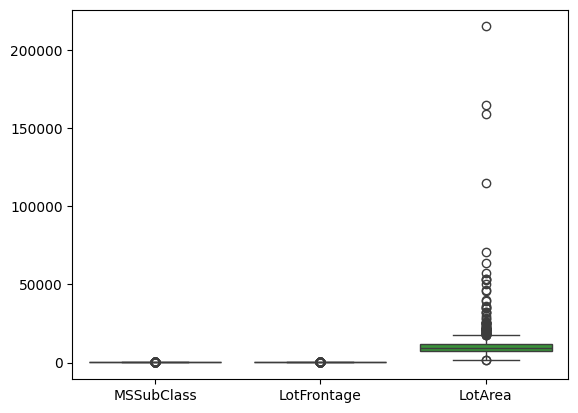

In [15]:
sns.boxplot(data.iloc[:, 1:5])

In [16]:
len(data.columns)

75

<Axes: >

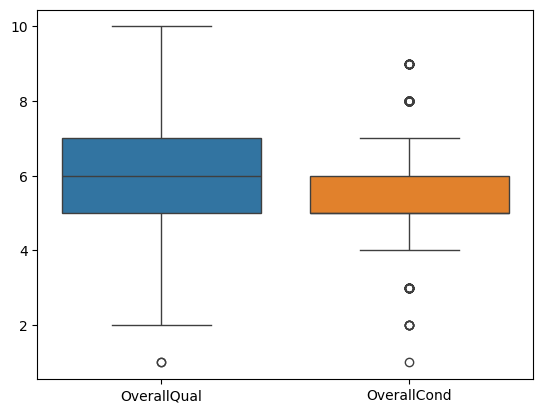

In [17]:
sns.boxplot(data.iloc[:, 16:18])

<Axes: >

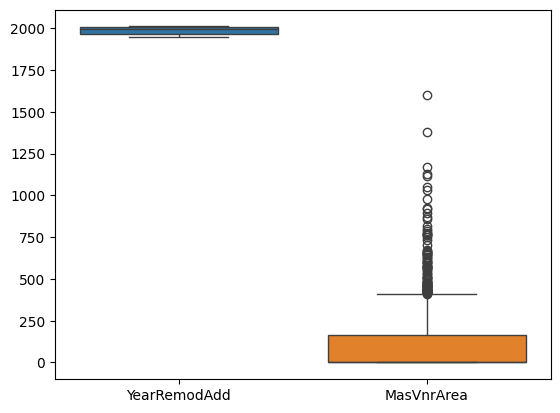

In [18]:
sns.boxplot(data.iloc[:, 19:25])

In [19]:
data2 = data.copy()
data3 = data.copy()

In [20]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'Enclo

In [21]:
X = data.drop(["SalePrice", 'Id'], axis=1)
y = data['SalePrice']

In [22]:
X.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal


In [23]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [24]:
X = pd.get_dummies(X)
X.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,False,False,False,True,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,False,False,False,True,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False


In [25]:
X = X.astype('float32')

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [27]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

In [28]:
rs = RobustScaler()
rs_X_train = rs.fit_transform(X_train)
rs_X_valid = rs.transform(X_valid)


In [31]:
import os
import joblib

# 디렉토리 생성
os.makedirs('./model', exist_ok=True)

# 객체 저장
joblib.dump(rs, './model/iowa_rs.joblib')

['./model/iowa_rs.joblib']

# 출력층 Dense(1) 
# model.compile(loss='mean_squared_error', metrics='mse')

In [32]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import RootMeanSquaredError

2025-05-23 09:42:19.877638: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-23 09:42:19.888082: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747960939.899404     677 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747960939.903236     677 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747960939.913169     677 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [33]:
inputs = Input(shape=(rs_X_train.shape[1], ))
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1)(x)
base_model = Model(inputs=inputs, outputs=outputs)
base_model.summary()


I0000 00:00:1747960958.330237     677 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 266)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
base_model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_path = "./model/iowa_base_model_best.keras"
check_point = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)
base_model_history = base_model.fit(rs_X_train, y_train, epochs=1000, batch_size=32,
                                   validation_data=(rs_X_valid, y_valid),
                                   callbacks=[early_stop, check_point],
                                   verbose=1)

Epoch 1/1000


I0000 00:00:1747961251.336311     737 service.cc:152] XLA service 0x7f9ca801cdc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747961251.336377     737 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-23 09:47:31.379479: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747961251.562939     737 cuda_dnn.cc:529] Loaded cuDNN version 90300


22/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37513916416.0000 - root_mean_squared_error: 193605.9375

I0000 00:00:1747961253.346222     737 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 37684260864.0000 - root_mean_squared_error: 194067.3125
Epoch 1: val_loss improved from inf to 39378571264.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 37720915968.0000 - root_mean_squared_error: 194162.7188 - val_loss: 39378571264.0000 - val_root_mean_squared_error: 198440.3438
Epoch 2/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38919909376.0000 - root_mean_squared_error: 197261.5000
Epoch 2: val_loss improved from 39378571264.00000 to 39371161600.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 38916784128.0000 - root_mean_squared_error: 197255.3750 - val_loss: 39371161600.0000 - val_root_mean_squared_error: 198421.6719
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38619025408.0000 - root_mean_squared_error: 196468.9844
Epoch 3: val_loss improved from 39371161600.00000 to 39360090112.00000, saving m

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4148475648.0000 - root_mean_squared_error: 64369.9297
Epoch 156: val_loss improved from 2070481152.00000 to 2069475584.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4152813568.0000 - root_mean_squared_error: 64404.4961 - val_loss: 2069475584.0000 - val_root_mean_squared_error: 45491.4883
Epoch 157/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5198821376.0000 - root_mean_squared_error: 71922.3359
Epoch 157: val_loss did not improve from 2069475584.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5122257920.0000 - root_mean_squared_error: 71405.1094 - val_loss: 2092906112.0000 - val_root_mean_squared_error: 45748.2891
Epoch 158/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4392624640.0000 - root_mean_squared_error: 66191.5078
Epoch 158: val_loss did not improve from 2069475584.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4476596736.0000 - root_mean_squared_

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5323014144.0000 - root_mean_squared_error: 72635.9141
Epoch 175: val_loss did not improve from 2026731136.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5322748928.0000 - root_mean_squared_error: 72673.2031 - val_loss: 2051802880.0000 - val_root_mean_squared_error: 45296.8320
Epoch 176/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4922552320.0000 - root_mean_squared_error: 70018.1719
Epoch 176: val_loss did not improve from 2026731136.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4852155392.0000 - root_mean_squared_error: 69531.0625 - val_loss: 2035613568.0000 - val_root_mean_squared_error: 45117.7734
Epoch 177/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3778077952.0000 - root_mean_squared_error: 61054.2188
Epoch 177: val_loss improved from 2026731136.00000 to 2013086976.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3818343424.0000 - root_mean_squared_err

23/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3871145216.0000 - root_mean_squared_error: 62145.2930
Epoch 194: val_loss did not improve from 1942062976.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3921037312.0000 - root_mean_squared_error: 62563.3203 - val_loss: 1963793152.0000 - val_root_mean_squared_error: 44314.7031
Epoch 195/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3478861312.0000 - root_mean_squared_error: 58795.6328
Epoch 195: val_loss did not improve from 1942062976.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3558329856.0000 - root_mean_squared_error: 59462.7891 - val_loss: 1948370560.0000 - val_root_mean_squared_error: 44140.3516
Epoch 196/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3829642240.0000 - root_mean_squared_error: 61644.7383
Epoch 196: val_loss did not improve from 1942062976.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3907752704.0000 - root_mean_squared_error: 62265.6875 - val_loss: 1958494592.0000 - val_root_mean_squ

Epoch 213/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4488256000.0000 - root_mean_squared_error: 66710.8047
Epoch 213: val_loss did not improve from 1834328448.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4484285952.0000 - root_mean_squared_error: 66706.8750 - val_loss: 1879402752.0000 - val_root_mean_squared_error: 43352.0781
Epoch 214/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3469755136.0000 - root_mean_squared_error: 58846.4648
Epoch 214: val_loss did not improve from 1834328448.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3568881664.0000 - root_mean_squared_error: 59673.1172 - val_loss: 1861389440.0000 - val_root_mean_squared_error: 43143.8203
Epoch 215/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4512409088.0000 - root_mean_squared_error: 67134.5234
Epoch 215: val_loss did not improve from 1834328448.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4498802176.0000 - root_mean_squared_error: 67037.3828 - val_loss: 1863479552.0000 - va

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3638633984.0000 - root_mean_squared_error: 60280.2344 - val_loss: 1763829760.0000 - val_root_mean_squared_error: 41997.9727
Epoch 233/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3920163072.0000 - root_mean_squared_error: 62540.2656
Epoch 233: val_loss did not improve from 1763829760.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3925008128.0000 - root_mean_squared_error: 62585.2383 - val_loss: 1805060736.0000 - val_root_mean_squared_error: 42486.0078
Epoch 234/1000
21/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5095859712.0000 - root_mean_squared_error: 71189.5234
Epoch 234: val_loss did not improve from 1763829760.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4806643200.0000 - root_mean_squared_error: 69144.5703 - val_loss: 1785110144.0000 - val_root_mean_squared_error: 42250.5625
Epoch 235/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5809740800.0000 - root_mean_squared_error: 75745.2578
Epoch 235: val_loss did

In [35]:
pred = base_model.predict(rs_X_valid)
pred = pd.DataFrame(pred, columns=['pred'])
pred

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


,pred
0,125078.632812
1,272772.625000
2,88047.164062
3,127146.078125
4,269868.593750
...,...
433,86660.734375
434,112756.164062
435,166996.078125
436,149667.687500


In [36]:
y_valid = pd.DataFrame(y_valid)
y_valid_df = y_valid.reset_index(drop=True)
final_result = y_valid_df.join(pred)
final_result

,SalePrice,pred
0,154500,125078.632812
1,325000,272772.625000
2,115000,88047.164062
3,159000,127146.078125
4,315500,269868.593750
...,...,...
433,139000,86660.734375
434,126175,112756.164062
435,205950,166996.078125
436,110000,149667.687500


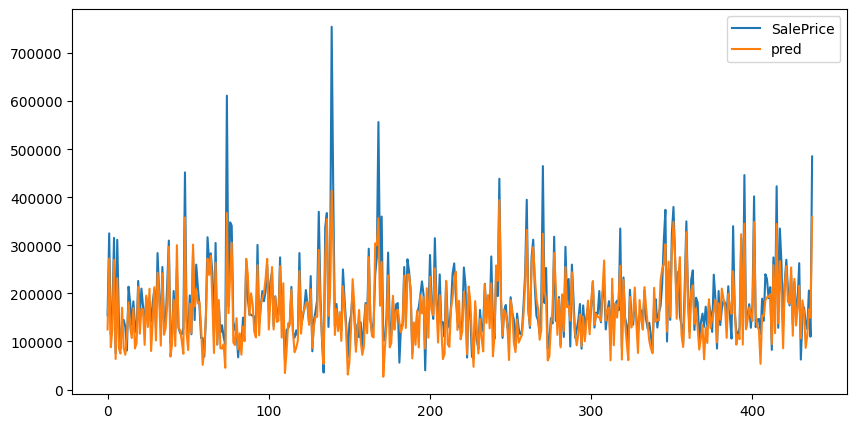

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1867891200.0000 - root_mean_squared_error: 43094.7109
[1763829760.0, 41997.97265625]


In [37]:
plt.figure(figsize=(10,5))
plt.plot(final_result['SalePrice'], label='SalePrice')
plt.plot(final_result['pred'], label='pred')
plt.legend()
plt.show()
print(base_model.evaluate(rs_X_valid, y_valid))

# 많은 컬럼 중에 어떤 컬럼을 선택? 266개
* 컬럼의 상관분석을 통해 타겟 변수(종속변수)와 상관도가 높은 컬럼만 선택
* 트리계열 알고리즘을 사용해 분석 후 중요한 변수만 추출해서 재분석

In [39]:
data2

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,0,4,2010,WD,Normal,142125


In [40]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [41]:
data2.drop('Id', axis=1, inplace=True)

In [42]:
data2 = pd.get_dummies(data2)
data2.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False


상관분석

In [43]:
# data2['SalePrice']

In [44]:
corr_rate = data2.corr(method='spearman')['SalePrice'].sort_values(ascending=False)

In [45]:
new_cols1 = corr_rate.head(15).index
new_cols1

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'YearBuilt',
       'GarageArea', 'FullBath', 'TotalBsmtSF', '1stFlrSF', 'ExterQual_Gd',
       'YearRemodAdd', 'GarageYrBlt', 'Foundation_PConc', 'TotRmsAbvGrd',
       'Fireplaces'],
      dtype='object')

In [46]:
new_cols2 = corr_rate.tail(4).index
new_cols2

Index(['KitchenQual_TA', 'BsmtQual_TA', 'GarageFinish_Unf', 'ExterQual_TA'], dtype='object')

In [47]:
final_cols = list(new_cols1) + list(new_cols2)
final_cols

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'YearBuilt',
 'GarageArea',
 'FullBath',
 'TotalBsmtSF',
 '1stFlrSF',
 'ExterQual_Gd',
 'YearRemodAdd',
 'GarageYrBlt',
 'Foundation_PConc',
 'TotRmsAbvGrd',
 'Fireplaces',
 'KitchenQual_TA',
 'BsmtQual_TA',
 'GarageFinish_Unf',
 'ExterQual_TA']

In [48]:
final_cols

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'YearBuilt',
 'GarageArea',
 'FullBath',
 'TotalBsmtSF',
 '1stFlrSF',
 'ExterQual_Gd',
 'YearRemodAdd',
 'GarageYrBlt',
 'Foundation_PConc',
 'TotRmsAbvGrd',
 'Fireplaces',
 'KitchenQual_TA',
 'BsmtQual_TA',
 'GarageFinish_Unf',
 'ExterQual_TA']

In [49]:
data2

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,223500,False,False,False,True,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,140000,False,False,False,True,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,250000,False,False,False,True,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [50]:
final_df = data2[final_cols]

In [51]:
final_df

,SalePrice,OverallQual,GrLivArea,GarageCars,YearBuilt,GarageArea,FullBath,TotalBsmtSF,1stFlrSF,ExterQual_Gd,YearRemodAdd,GarageYrBlt,Foundation_PConc,TotRmsAbvGrd,Fireplaces,KitchenQual_TA,BsmtQual_TA,GarageFinish_Unf,ExterQual_TA
0,208500,7,1710,2,2003,548,2,856,856,True,2003,2003.0,True,8,0,False,False,False,False
1,181500,6,1262,2,1976,460,2,1262,1262,False,1976,1976.0,False,6,1,True,False,False,True
2,223500,7,1786,2,2001,608,2,920,920,True,2002,2001.0,True,6,1,False,False,False,False
3,140000,7,1717,3,1915,642,1,756,961,False,1970,1998.0,False,7,1,False,True,True,True
4,250000,8,2198,3,2000,836,2,1145,1145,True,2000,2000.0,True,9,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,175000,6,1647,2,1999,460,2,953,953,False,2000,1999.0,True,7,1,True,False,False,True
1456,210000,6,2073,2,1978,500,2,1542,2073,False,1988,1978.0,False,7,2,True,False,True,True
1457,266500,7,2340,1,1941,252,2,1152,1188,False,2006,1941.0,False,9,2,False,True,False,False
1458,142125,5,1078,1,1950,240,1,1078,1078,False,1996,1950.0,False,5,0,False,True,True,True


In [52]:
final_df.corr(method='spearman')

,SalePrice,OverallQual,GrLivArea,GarageCars,YearBuilt,GarageArea,FullBath,TotalBsmtSF,1stFlrSF,ExterQual_Gd,YearRemodAdd,GarageYrBlt,Foundation_PConc,TotRmsAbvGrd,Fireplaces,KitchenQual_TA,BsmtQual_TA,GarageFinish_Unf,ExterQual_TA
SalePrice,1.000000,0.809829,0.731310,0.690711,0.652682,0.649379,0.635957,0.602725,0.575408,0.574642,0.571159,0.563256,0.562287,0.532586,0.519247,-0.581803,-0.583512,-0.620915,-0.637785
OverallQual,0.809829,1.000000,0.603262,0.608756,0.647392,0.541552,0.576372,0.459915,0.408730,0.603276,0.557723,0.592010,0.586764,0.427806,0.420626,-0.581192,-0.590344,-0.556712,-0.673842
GrLivArea,0.731310,0.603262,1.000000,0.505094,0.288493,0.468211,0.658419,0.371026,0.494421,0.358133,0.282400,0.274625,0.332373,0.827874,0.480804,-0.376159,-0.338674,-0.362334,-0.413922
GarageCars,0.690711,0.608756,0.505094,1.000000,0.601519,0.853317,0.518310,0.455508,0.450580,0.443029,0.456245,0.564786,0.480178,0.386244,0.325520,-0.423255,-0.504415,-0.489950,-0.506121
YearBuilt,0.652682,0.647392,0.288493,0.601519,1.000000,0.528281,0.537420,0.427187,0.293363,0.593575,0.684388,0.845595,0.704001,0.176820,0.174655,-0.512248,-0.700552,-0.632360,-0.644772
GarageArea,0.649379,0.541552,0.468211,0.853317,0.528281,1.000000,0.444459,0.486685,0.489797,0.389859,0.398267,0.540450,0.400205,0.330549,0.264543,-0.393538,-0.413167,-0.449457,-0.453014
FullBath,0.635957,0.576372,0.658419,0.518310,0.537420,0.444459,1.000000,0.328036,0.366891,0.449973,0.431390,0.524892,0.480765,0.558665,0.268548,-0.430333,-0.513693,-0.450629,-0.485598
TotalBsmtSF,0.602725,0.459915,0.371026,0.455508,0.427187,0.486685,0.328036,1.000000,0.829292,0.313044,0.299042,0.319936,0.296406,0.233913,0.325687,-0.307764,-0.317195,-0.385379,-0.383999
1stFlrSF,0.575408,0.408730,0.494421,0.450580,0.293363,0.489797,0.366891,0.829292,1.000000,0.225259,0.240265,0.214327,0.179926,0.361777,0.394883,-0.268281,-0.215559,-0.326525,-0.294636
ExterQual_Gd,0.574642,0.603276,0.358133,0.443029,0.593575,0.389859,0.449973,0.313044,0.225259,1.000000,0.532550,0.569570,0.586748,0.212665,0.181413,-0.617598,-0.541969,-0.483784,-0.906121


<Axes: >

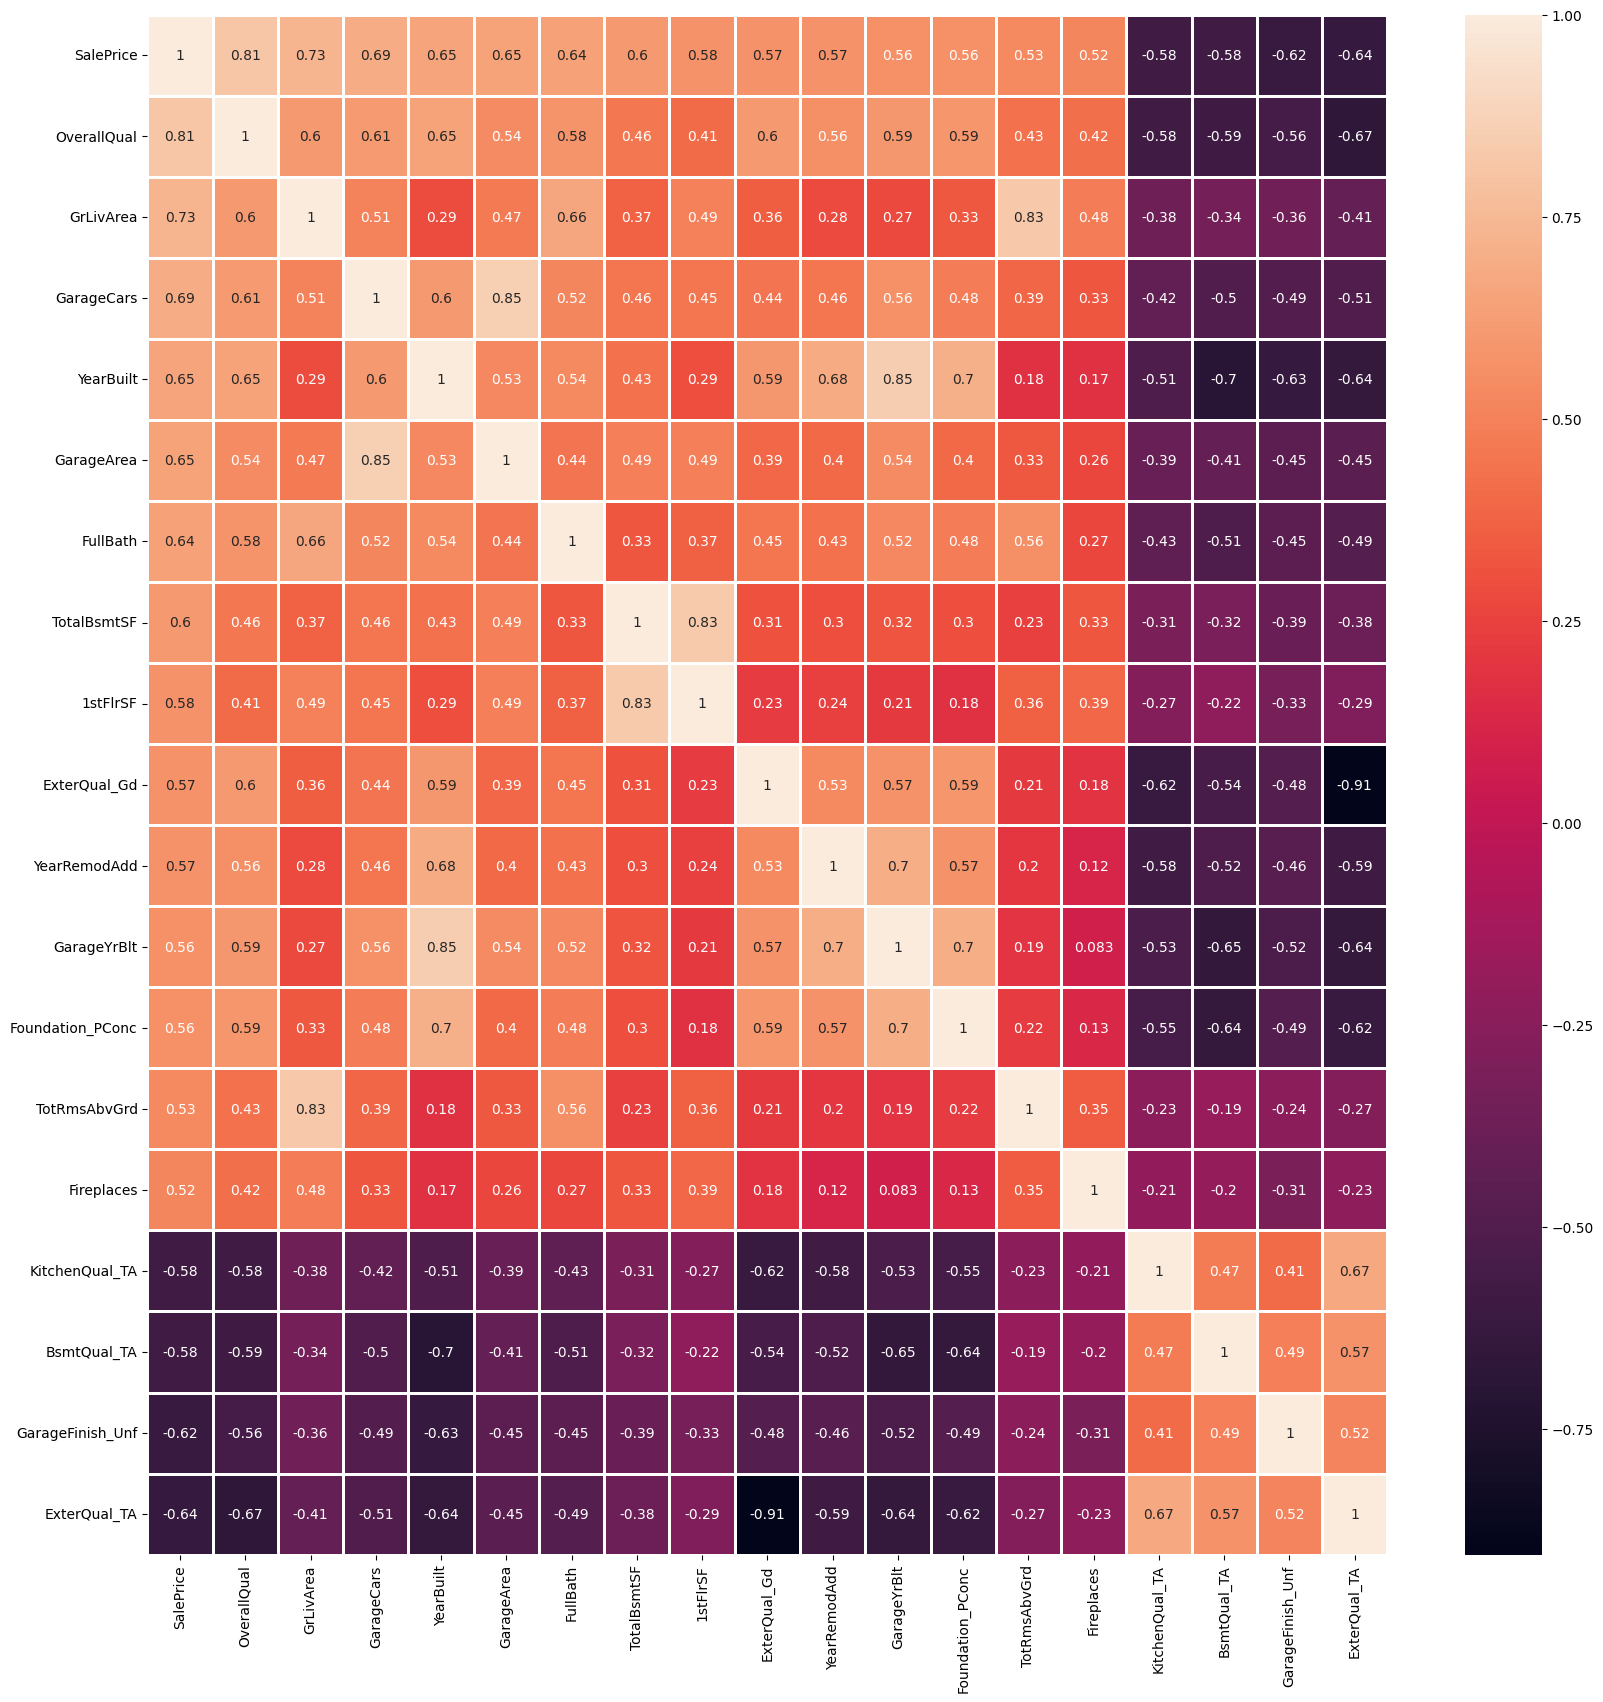

In [53]:
plt.figure(figsize=(20,20))
sns.heatmap(final_df.corr(method='spearman'), annot=True, linewidths=1)

In [54]:
ExterQual_TA - ExterQual_Gd -0.91
BsmtQual_TA - YearBuilt -0.7
BsmtQual_TA - YearBuilt 0.7
TotRmsAbvGrd - GrLivArea 0.83

SyntaxError: invalid syntax (1730232521.py, line 3)

In [55]:
final_df = final_df.drop(['BsmtQual_TA', 'TotRmsAbvGrd','ExterQual_Gd'], axis=1)

In [56]:
X2 = final_df.drop('SalePrice', axis=1)
y2 = final_df['SalePrice']

In [57]:
X2

,OverallQual,GrLivArea,GarageCars,YearBuilt,GarageArea,FullBath,TotalBsmtSF,1stFlrSF,YearRemodAdd,GarageYrBlt,Foundation_PConc,Fireplaces,KitchenQual_TA,GarageFinish_Unf,ExterQual_TA
0,7,1710,2,2003,548,2,856,856,2003,2003.0,True,0,False,False,False
1,6,1262,2,1976,460,2,1262,1262,1976,1976.0,False,1,True,False,True
2,7,1786,2,2001,608,2,920,920,2002,2001.0,True,1,False,False,False
3,7,1717,3,1915,642,1,756,961,1970,1998.0,False,1,False,True,True
4,8,2198,3,2000,836,2,1145,1145,2000,2000.0,True,1,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,1999,460,2,953,953,2000,1999.0,True,1,True,False,True
1456,6,2073,2,1978,500,2,1542,2073,1988,1978.0,False,2,True,True,True
1457,7,2340,1,1941,252,2,1152,1188,2006,1941.0,False,2,False,False,False
1458,5,1078,1,1950,240,1,1078,1078,1996,1950.0,False,0,False,True,True


In [58]:
X2_train, X2_valid, y2_train, y2_valid = train_test_split(X2, y2, test_size=0.3, random_state=42)

In [59]:
rs2 = RobustScaler()
rs2_X2_tarin = rs2.fit_transform(X2_train)
rs2_X2_valid = rs2.transform(X2_valid)

In [60]:
rs2_X2_tarin = rs2_X2_tarin.astype('float32')
rs2_X2_valid = rs2_X2_valid.astype('float32')

In [61]:
inputs = Input(shape=(rs2_X2_tarin.shape[1], ))
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1)(x)
corr_select_model = Model(inputs=inputs, outputs=outputs)
corr_select_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
corr_select_model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_path = "./model/iowa_corr_select_model_best.keras"
check_point = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)
corr_select_model_history = corr_select_model.fit(rs2_X2_tarin, y2_train, epochs=1000, batch_size=32,
                                   validation_data=(rs2_X2_valid, y2_valid),
                                   callbacks=[early_stop, check_point],
                                   verbose=1)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 39942823936.0000 - root_mean_squared_error: 199835.0781
Epoch 1: val_loss improved from inf to 39380455424.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 39911002112.0000 - root_mean_squared_error: 199755.6094 - val_loss: 39380455424.0000 - val_root_mean_squared_error: 198445.0938
Epoch 2/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38000988160.0000 - root_mean_squared_error: 194897.0312
Epoch 2: val_loss improved from 39380455424.00000 to 39379632128.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 38054993920.0000 - root_mean_squared_error: 195037.2500 - val_loss: 39379632128.0000 - val_root_mean_squared_error: 198443.0156
Epoch 3/1000
18/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 40589586432.0000 - root_mean_squared_error: 201337.6094
Epoch 3: val_loss improved from 39379632128.00000 to 

Epoch 18/1000
24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 39447212032.0000 - root_mean_squared_error: 198567.3594
Epoch 18: val_loss improved from 38844264448.00000 to 38739349504.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 39168024576.0000 - root_mean_squared_error: 197872.2969 - val_loss: 38739349504.0000 - val_root_mean_squared_error: 196823.1406
Epoch 19/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40077078528.0000 - root_mean_squared_error: 200091.2188
Epoch 19: val_loss improved from 38739349504.00000 to 38624899072.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 39862169600.0000 - root_mean_squared_error: 199560.6406 - val_loss: 38624899072.0000 - val_root_mean_squared_error: 196532.1875
Epoch 20/1000
18/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36255059968.0000 - root_mean_squared_error: 190376.5781 
Epoch 20: val_loss improved from 38

Epoch 35/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33796270080.0000 - root_mean_squared_error: 183823.0469
Epoch 35: val_loss improved from 35302490112.00000 to 34977980416.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 33973714944.0000 - root_mean_squared_error: 184304.8594 - val_loss: 34977980416.0000 - val_root_mean_squared_error: 187024.0000
Epoch 36/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35551354880.0000 - root_mean_squared_error: 188484.1875
Epoch 36: val_loss improved from 34977980416.00000 to 34627461120.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 35439271936.0000 - root_mean_squared_error: 188190.4062 - val_loss: 34627461120.0000 - val_root_mean_squared_error: 186084.5469
Epoch 37/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33026967552.0000 - root_mean_squared_error: 181697.7031
Epoch 37: val_loss improved from 3462

Epoch 52/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28209721344.0000 - root_mean_squared_error: 167893.1406
Epoch 52: val_loss improved from 28085121024.00000 to 27584362496.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28190740480.0000 - root_mean_squared_error: 167838.2656 - val_loss: 27584362496.0000 - val_root_mean_squared_error: 166085.4062
Epoch 53/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27023071232.0000 - root_mean_squared_error: 164365.3750
Epoch 53: val_loss improved from 27584362496.00000 to 27058388992.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 27033421824.0000 - root_mean_squared_error: 164400.6562 - val_loss: 27058388992.0000 - val_root_mean_squared_error: 164494.3438
Epoch 54/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27650664448.0000 - root_mean_squared_error: 166242.2500
Epoch 54: val_loss improved from 2705

Epoch 69/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19142514688.0000 - root_mean_squared_error: 138353.2344
Epoch 69: val_loss improved from 19042932736.00000 to 18527961088.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19135031296.0000 - root_mean_squared_error: 138326.3438 - val_loss: 18527961088.0000 - val_root_mean_squared_error: 136117.4531
Epoch 70/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19045625856.0000 - root_mean_squared_error: 137925.0312
Epoch 70: val_loss improved from 18527961088.00000 to 18004559872.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 18852761600.0000 - root_mean_squared_error: 137230.9219 - val_loss: 18004559872.0000 - val_root_mean_squared_error: 134181.0625
Epoch 71/1000
20/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17384292352.0000 - root_mean_squared_error: 131772.8438
Epoch 71: val_loss improved from 1800

...

26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5546060800.0000 - root_mean_squared_error: 73740.9531
Epoch 334: val_loss did not improve from 2296093952.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5320609792.0000 - root_mean_squared_error: 72301.8203 - val_loss: 2302679040.0000 - val_root_mean_squared_error: 47986.2383
Epoch 335/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5237188608.0000 - root_mean_squared_error: 72243.6406
Epoch 335: val_loss improved from 2296093952.00000 to 2292973568.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5098987520.0000 - root_mean_squared_error: 71290.9141 - val_loss: 2292973568.0000 - val_root_mean_squared_error: 47885.0039
Epoch 336/1000
14/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3797352704.0000 - root_mean_squared_error: 61526.6680 
Epoch 336: val_loss improved from 2292973568.00000 to 2286125056.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4871220224.0000 - root_mean_squared_error: 69722.4297
Epoch 352: val_loss did not improve from 2247080960.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4875767296.0000 - root_mean_squared_error: 69756.9297 - val_loss: 2256230912.0000 - val_root_mean_squared_error: 47499.7969
Epoch 353/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4080237568.0000 - root_mean_squared_error: 63721.7070
Epoch 353: val_loss improved from 2247080960.00000 to 2242829056.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4108558592.0000 - root_mean_squared_error: 63953.2539 - val_loss: 2242829056.0000 - val_root_mean_squared_error: 47358.5156
Epoch 354/1000
17/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4205660928.0000 - root_mean_squared_error: 64533.3242 
Epoch 354: val_loss improved from 2242829056.00000 to 2227250432.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/3

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3465977344.0000 - root_mean_squared_error: 58830.0898
Epoch 370: val_loss did not improve from 2165668608.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3536869376.0000 - root_mean_squared_error: 59413.8555 - val_loss: 2167568128.0000 - val_root_mean_squared_error: 46557.1484
Epoch 371/1000
21/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3837083136.0000 - root_mean_squared_error: 61656.8672
Epoch 371: val_loss did not improve from 2165668608.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3848817664.0000 - root_mean_squared_error: 61855.3828 - val_loss: 2168083200.0000 - val_root_mean_squared_error: 46562.6797
Epoch 372/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4146742784.0000 - root_mean_squared_error: 64231.0117
Epoch 372: val_loss did not improve from 2165668608.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4171159296.0000 - root_mean_squared_error: 64458.7305 - val_loss: 2166255616.0000 - val_root_mean_square

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4246243840.0000 - root_mean_squared_error: 65076.6445 - val_loss: 2131384448.0000 - val_root_mean_squared_error: 46166.9180
Epoch 389/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4241551616.0000 - root_mean_squared_error: 65010.2383
Epoch 389: val_loss did not improve from 2131384448.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4244393216.0000 - root_mean_squared_error: 65035.4805 - val_loss: 2133553536.0000 - val_root_mean_squared_error: 46190.4062
Epoch 390/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4466789376.0000 - root_mean_squared_error: 66768.7109
Epoch 390: val_loss improved from 2131384448.00000 to 2123492864.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4436779008.0000 - root_mean_squared_error: 66557.3750 - val_loss: 2123492864.0000 - val_root_mean_squared_error: 46081.3711
Epoch 391/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38450

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4096505088.0000 - root_mean_squared_error: 63901.9531 - val_loss: 2081361408.0000 - val_root_mean_squared_error: 45621.9375
Epoch 407/1000
23/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3921038336.0000 - root_mean_squared_error: 62432.1758
Epoch 407: val_loss did not improve from 2056719488.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3929899008.0000 - root_mean_squared_error: 62558.8594 - val_loss: 2074631424.0000 - val_root_mean_squared_error: 45548.1211
Epoch 408/1000
17/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4131586048.0000 - root_mean_squared_error: 64260.9570 
Epoch 408: val_loss did not improve from 2056719488.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4201160192.0000 - root_mean_squared_error: 64788.1250 - val_loss: 2062683392.0000 - val_root_mean_squared_error: 45416.7734
Epoch 409/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3593548800.0000 - root_mean_squared_error: 59850.3477
Epoch 409: val_loss di

In [63]:
pred = corr_select_model.predict(rs2_X2_valid)
pred = pd.DataFrame(pred, columns=['pred'])
pred

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


,pred
0,77092.781250
1,307137.281250
2,108211.125000
3,129149.953125
4,287955.281250
...,...
433,73245.726562
434,73329.968750
435,198733.828125
436,116619.328125


In [64]:
y2_valid = pd.DataFrame(y2_valid)
y2_valid_df = y2_valid.reset_index(drop=True)
final_result = y2_valid_df.join(pred)
final_result

,SalePrice,pred
0,154500,77092.781250
1,325000,307137.281250
2,115000,108211.125000
3,159000,129149.953125
4,315500,287955.281250
...,...,...
433,139000,73245.726562
434,126175,73329.968750
435,205950,198733.828125
436,110000,116619.328125


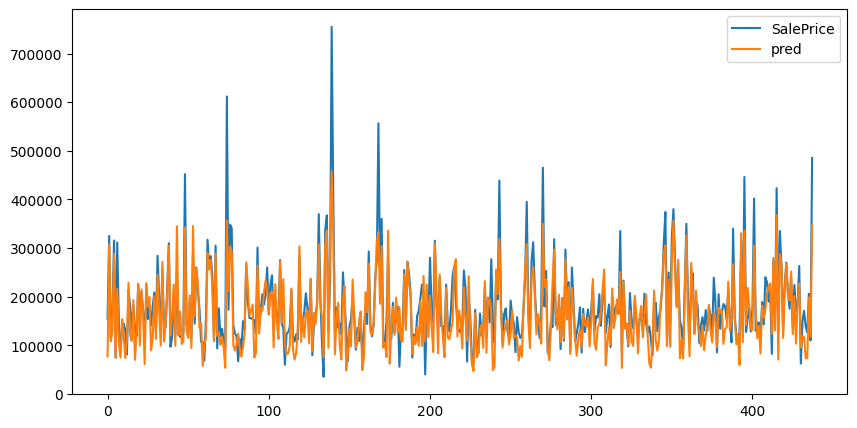

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2108262272.0000 - root_mean_squared_error: 45802.0586
[2056719488.0, 45351.0703125]


In [65]:
plt.figure(figsize=(10,5))
plt.plot(final_result['SalePrice'], label='SalePrice')
plt.plot(final_result['pred'], label='pred')
plt.legend()
plt.show()
print(corr_select_model.evaluate(rs2_X2_valid, y2_valid))